# Interval type-2 (IT2)

IT2 sets carry a *footprint of uncertainty* (FOU). Rules use the same operator syntax; the engine type-reduces with Karnik-Mendel.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import fuzzytool as fz
from fuzzytool import datasets, viz

## A set with an FOU

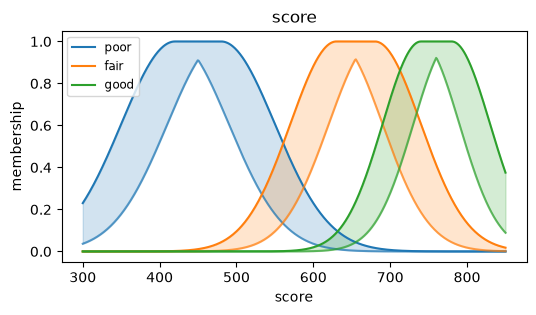

In [2]:
score = fz.Variable('score', (300, 850))
score['poor'] = fz.it2_gauss_uncertain_mean(420, 480, 70)
score['fair'] = fz.it2_gauss_uncertain_mean(630, 680, 60)
score['good'] = fz.it2_gauss_uncertain_mean(740, 780, 50)
viz.plot_it2_variable(score); plt.show()

## IT2 inference vs type-1

Compare the type-1 and IT2 credit-risk systems across the score range.

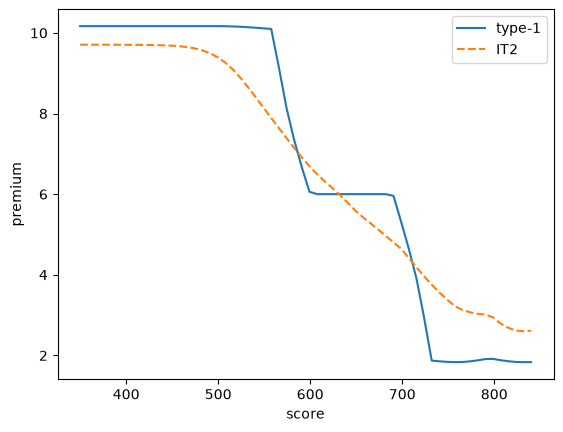

In [3]:
t1, *_ = datasets.credit_risk()
t2, *_ = datasets.credit_risk_it2()
xs = np.linspace(350, 840, 60)
y1 = [t1(score=s, dti=25) for s in xs]
y2 = [t2(score=s, dti=25) for s in xs]
plt.plot(xs, y1, label='type-1')
plt.plot(xs, y2, '--', label='IT2')
plt.xlabel('score'); plt.ylabel('premium'); plt.legend(); plt.show()